# Linear data creation

## Method

Questions TO DO:

Packages used:
+ DoWhy - setting up causal graph
+ e - for drawing causal graph

Resources:
+ d

## Code setup

In [1]:
import numpy as np  # generate data
import pandas as pd  # display data nicely
import os  # save files

# Update some functions in networkx v3.5 that are incompatible
# with this version of DoWhy v0.8.
import networkx as nx
nx.algorithms.d_separated = nx.algorithms.d_separation.is_d_separator
nx.d_separated = nx.algorithms.d_separation.is_d_separator

import dowhy
from dowhy import CausalModel

import matplotlib.pyplot as plt

## Built-in linear dataset generator

In [2]:
import dowhy.datasets

In [3]:
data = dowhy.datasets.linear_dataset(
    beta=10,  # true causal effect
    num_common_causes=3,
    num_instruments=1,
    num_effect_modifiers=1,
    num_samples=5000,
    treatment_is_binary=True,
    stddev_treatment_noise=10,
    num_discrete_common_causes=1
    )

In [4]:
df = data["df"]

Explanation of which generated variable names are which types of variable:

In [5]:
name_keys = [k for k in data.keys() if 'name' in k]

for k in name_keys:
    print(f'| {k:>30s} | {str(data[k]):30s} |')

|                 treatment_name | ['v0']                         |
|                   outcome_name | y                              |
|            common_causes_names | ['W0', 'W1', 'W2']             |
|               instrument_names | ['Z0']                         |
|          effect_modifier_names | ['X0']                         |
|      frontdoor_variables_names | []                             |


View the graph of the data:

In [6]:
# With graph
model = CausalModel(
    data = df,
    treatment=data["treatment_name"],
    outcome=data["outcome_name"],
    graph=data["gml_graph"]
    )

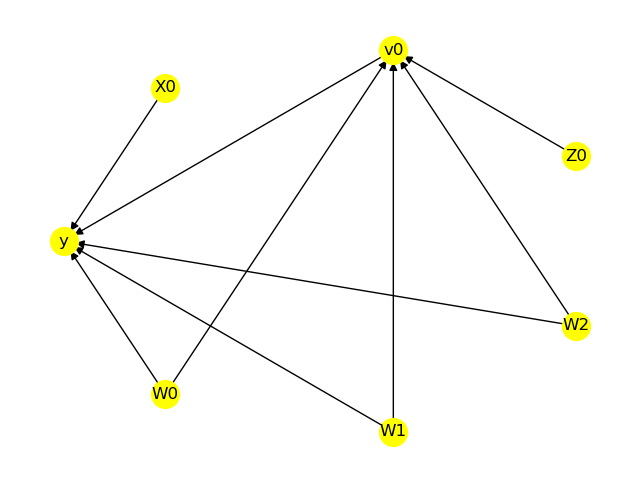

In [7]:
model.view_model()

Pick out the average treatment effect:

In [8]:
data['ate']

Check the generated data:

In [9]:
df

,X0,Z0,W0,W1,W2,v0,y
0,-0.723302,1.0,-1.693817,1.494449,3,True,13.297974
1,1.255966,0.0,-1.170180,1.197508,2,True,19.595631
2,-0.270148,1.0,-0.821491,1.644991,1,True,14.895166
3,0.599395,1.0,0.113238,0.693078,3,True,21.494701
4,1.878962,0.0,0.224060,2.123020,0,True,26.953961
...,...,...,...,...,...,...,...
4995,-2.482888,0.0,-0.326000,1.521804,3,True,11.573282
4996,0.771915,1.0,0.812622,0.028066,1,True,17.952929
4997,-0.917256,0.0,-1.120616,-1.661220,2,True,-0.610002
4998,-1.162835,0.0,0.375973,-1.738287,1,False,-3.999127


In [10]:
df['W2']

0       3
1       2
2       1
3       3
4       0
       ..
4995    3
4996    1
4997    2
4998    1
4999    0
Name: W2, Length: 5000, dtype: category
Categories (4, int64): [0, 1, 2, 3]

In [11]:
import matplotlib.pyplot as plt

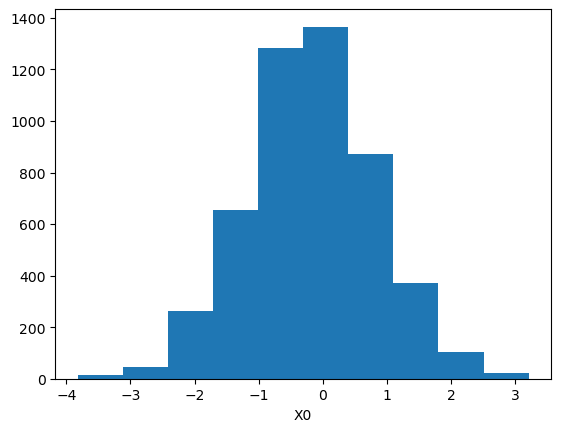

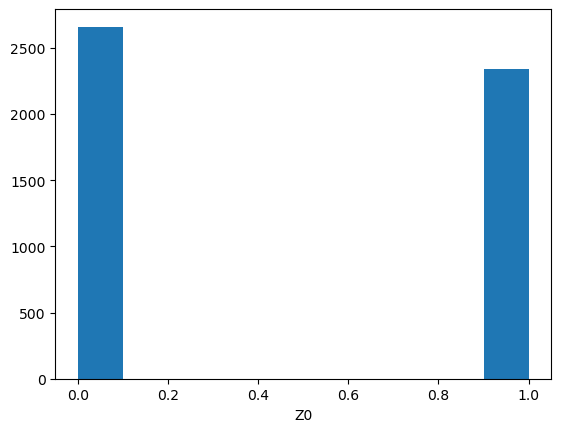

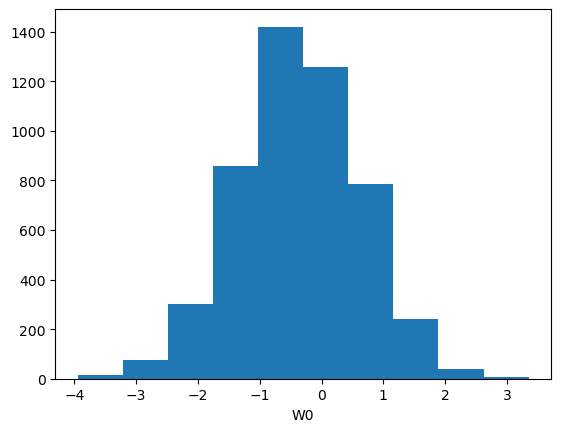

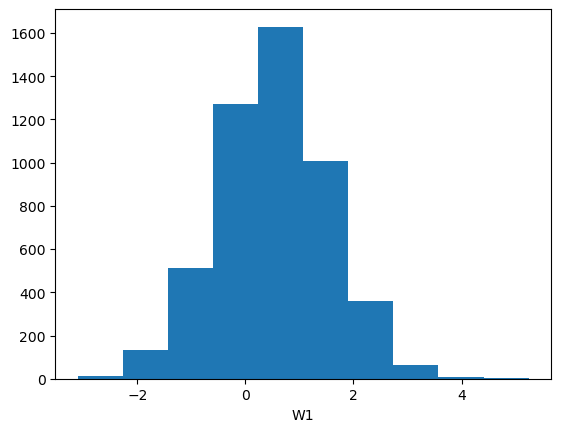

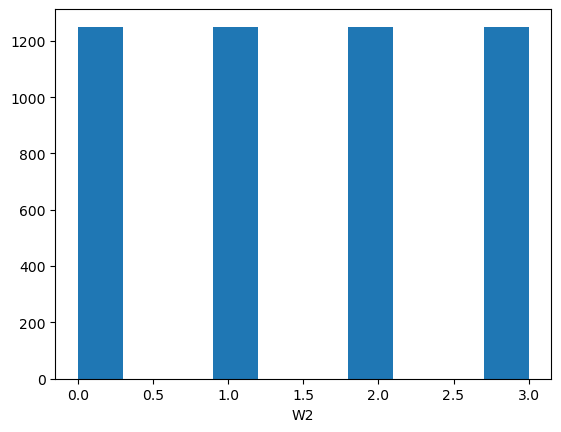

/home/anna/miniconda3/envs/synthetic_causal_test/lib/python3.13/site-packages/matplotlib/axes/_axes.py:7132: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  m, bins = np.histogram(x[i], bins, weights=w[i], **hist_kwargs)


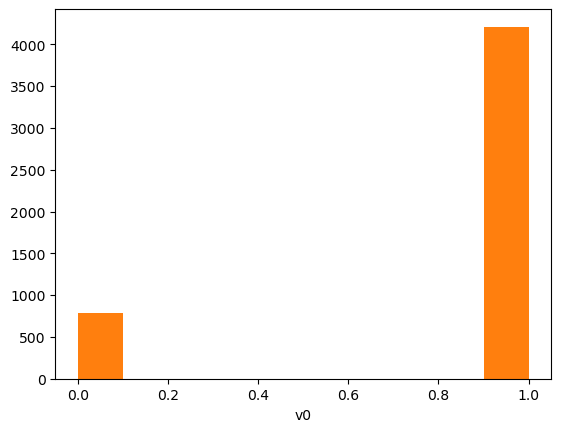

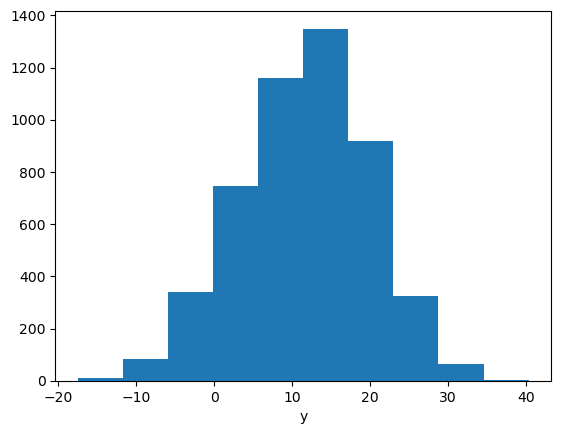

In [12]:
for c in df.columns:
    try:
        plt.hist(df[c])
    except TypeError:
        plt.hist(df[c].astype(float))
    plt.xlabel(c)
    plt.show()

## Generate data in style of built-in

The `linear_dataset` function generates random data and causal effects on the other variables. The data are then combined linearly to calculate further variables such as treatment decision, front-door variables, and outcomes.

The function also:
+ Calculates ATE by repeating the outcome calculations with two new sets of data and effect values, one set where all patients are treated and one set where all are not. The ATE is the mean of the differences in outcomes between the sets.
+ Creats a GML graph.

Notes:
+ $\beta$ means the causal effect(s) of treatment(s) on the outcome. These are given by the user. Either one value is shared between all treatments, or each treatment has its own effect size.
+ When there are multiple variables of the same type, for example multiple common causes, then the generated data and causal effects of each are independent of the other variables'. For example when data are generated using a multivariate_normal distribution, the diagonal covariance matrix makes it so that the variables are independent of each other.
+ Each instrumental variable affects all treatments.
+ Distribution types:
  + $U(0, 1)$ means a uniform distribution with range 0 to 1.
  + $N(\mu, \sigma$ is a normal distribution with mean $\mu$ and standard deviation $\sigma$.
  + $B(n, p)$ is a binomial distribution with $n$ trials and $p$ chance of success.
+ If discrete common causes or effect modifier variables are requested, then make a copy of the data and convert some of the variables' data to categorical by using quartiles 25%, 50%, 75% to split the data into four groups.
+ Common cause effects on treatment are labelled "1" and effects on outcomes are labelled "2".
+ Instrumental variables use a different generation method depending on their index in the list of all IVs. Even indices use a binomial distribution, odd use a uniform.
+ Treatment values can be converted to binary or categorical if required.
+ If front door variables are present then the outcome is calculated using these. Otherwise it is calculated using the treatment variable(s).



Generated data:

| Variable type | Affects | Generated data type | Expression | Generated data params | 
| --- | --- | --- | --- | --- |
| Common cause | Treatment, outcome | Normal | $N(\mu=m, 1)$ | Random mean $m$ sampled from uniform $U(-1, 1)$ and standard deviation 1 | 
| Instrumental variables (even index) | Treatment | Binomial | $B(1, p)$ | Single trial for random probability of success $p$ sampled from uniform $U(0, 1)$ | 
| Instrumental variables (odd index) | Treatment | Uniform | $U(0, 1)$ |
| Effect modifiers | Outcome | Normal | $N(\mu=m, 1)$ | Random mean $m$ sampled from uniform $U(-1, 1)$ and standard deviation 1 | 
| Noise for treatment | Treatment | Normal | $N(\mu=0, s)$ | User-defined standard deviation $s$ (default 1)  |
| Noise for front-door variable | Front-door | Normal | $N(\mu=0, 1)$ | Standard deviation 1  |
| Noise for outcome | Outcome | Normal | $N(\mu=0, s)$ | User-defined standard deviation $s$ (default 0.01)  |


Causal effects:

| Variable type | Affects | Effect type | Expression | Effect params |
| --- | --- | --- | --- | --- |
| Common cause | Treatment | Uniform | $U(0, x)$ | $x = 0.5 + 0.5 * \textnormal{max}[\textnormal{abs}(\beta)]$ |
| Common cause | Outcome | Uniform | $U(0, x)$ | $x = 0.5 + 0.5 * \textnormal{max}[\textnormal{abs}(\beta)]$ |
| Common cause | Front-door variable | Uniform | $U(0, x)$ | $x = 0.1 * \textnormal{effect of common cause on treatment}$ |
| Instrumental variable | Treatment | Uniform | $U(0.95x, 1.05x)$ | $x = 1 + \textnormal{max}[\textnormal{abs}(\beta)]$ |
| Effect modifier | Outcome | Uniform | $U(0, x)$ | $x = 0.5 + 0.5 * \textnormal{max}[\textnormal{abs}(\beta)]$ |
| Treatment | Front-door variable | Uniform | $U(0, x)$ | $x = 0.5 * \textnormal{max}[\textnormal{abs}(\beta)]$ |
| Front-door variable | Outcome | Uniform | $U(0, x)$ | $x = 0.5 * \textnormal{max}[\textnormal{abs}(\beta)]$ |


Calculated from existing data:

| Variable | Affected by | Calculation | 
| --- | --- | --- |
| Treatment | Common causes, IVs | Sum of: noise for treatment; common cause effect multiplied by common cause values; IV effect multiplied by IV values. |
| Front-door variable | Treatment | Sum of: noise for front-door variable; treatment effect multiplied by values; common cause effect multiplied by values. |
| Outcome | Front-door variable | Sum of: front-door effect multiplied by values; common cause effect multiplied by values; effect modifier effect multiplied by values multiplied by product of all treatment values. |
| Outcome | Treatment | Sum of: treatment effect multiplied by values; common cause effect multiplied by values; effect modifier effect multiplied by values multiplied by product of all treatment values. |

### Example linear dataset

Use the setup to create a linear dataset with three common causes, one instrumental variable, and one effect modifier. Skip any code relating to front door variables.

Explicitly give each variable its own object rather than creating and storing similar variable types together as in the dowhy linear_dataset module. Note: this is impractical for normal usage because adding or removing a variable means adding or removing many lines of code here, whereas the matrix methods in dowhy work the same for however many variables.

These functions are copied from the dowhy `linear_dataset` module. They are used to convert the treatment parameter to a binary treatment decision.

In [13]:
# Functions for converting treatment calculation to binary decision.

import math

# Functions from dowhy `datasets` module:
# https://www.pywhy.org/dowhy/v0.14/_modules/dowhy/datasets.html#linear_dataset

def sigmoid(x):
    return 1 / (1 + math.exp(-x))

def convert_to_binary(x, stochastic=True):
    p = sigmoid(x)
    if stochastic:
        return np.random.choice([0, 1], 1, p=[1 - p, p])
    else:
        return int(p > 0.5)

The following code creates the linear dataset and calculates the Average Treatment Effect in the same style as the dowhy module. We add in an extra column R0 that is unrelated to the rest of the data.

In [14]:
np.random.seed(42)

# This many patients:
num_samples = 1000

# For simplicity use only one treatment here.
treatment_effects = [5.0]
mab = max(np.abs(treatment_effects))
# Standard deviations of noise for treatment t and outcome y:
std_noise_t = 1
std_noise_y = 0.01

# Store randomly-generated parameters in here:
random_dict = dict(
    # Parameters for generating data:
    m_W0 = np.random.uniform(-1, 1),
    m_W1 = np.random.uniform(-1, 1),
    # m_W2 = np.random.uniform(-1, 1),
    p_Z0 = np.random.uniform(0, 1),
    m_X0 = np.random.uniform(-1, 1),
    m_R0 = np.random.uniform(-1, 1),
    # Parameters for generating causal effects on treatment:
    umax_W0_t = np.random.uniform(0, 0.5 + 0.5 * mab),
    umax_W1_t = np.random.uniform(0, 0.5 + 0.5 * mab),
    # umax_W2_t = np.random.uniform(0, 0.5 + 0.5 * mab),
    umax_Z0_t = np.random.uniform(0.95 * (1.0 + mab), 1.05 * (1.0 + mab)),
    # Parameters for generating causal effects on outcome:
    umax_W0_y = np.random.uniform(0, 0.5 + 0.5 * mab),
    umax_W1_y = np.random.uniform(0, 0.5 + 0.5 * mab),
    # umax_W2_y = np.random.uniform(0, 0.5 + 0.5 * mab),
    umax_X0_y = np.random.uniform(0, 0.5 + 0.5 * mab),
)
# Store causal effects in here:
causal_effect_dict = dict(
    # Generate causal effects (c) on treatment (t):
    c_W0_t = np.random.uniform(0, random_dict['umax_W0_t']),
    c_W1_t = np.random.uniform(0, random_dict['umax_W1_t']),
    # c_W2_t = np.random.uniform(0, random_dict['umax_W2_t']),
    c_Z0_t = np.random.uniform(0, random_dict['umax_Z0_t']),
    # Generate causal effects (c) on outcome (y):
    c_W0_y = np.random.uniform(0, random_dict['umax_W0_y']),
    c_W1_y = np.random.uniform(0, random_dict['umax_W1_y']),
    # c_W2_y = np.random.uniform(0, random_dict['umax_W2_y']),
    c_X0_y = np.random.uniform(0, random_dict['umax_X0_y']),
)
# Round:
for k, v in causal_effect_dict.items():
    causal_effect_dict[k] = round(v, 6)
for k, v in random_dict.items():
    random_dict[k] = round(v, 6)

# Generate data for common causes (W), instruments (Z), and effect modifiers (X):
W0 = np.random.normal(random_dict['m_W0'], 1, num_samples)
W1 = np.random.normal(random_dict['m_W1'], 1, num_samples)
# W2 = np.random.normal(random_dict['m_W2'], 1, num_samples)
Z0 = np.random.binomial(1, random_dict['p_Z0'], num_samples)
X0 = np.random.normal(random_dict['m_X0'], 1, num_samples)
R0 = np.random.normal(random_dict['m_R0'], 1, num_samples)

# Generate noise for combined data:
noise_t = np.random.normal(0, std_noise_t, num_samples)
noise_y, noise_y_t0, noise_y_t1 = [np.random.normal(0, std_noise_y, num_samples) for i in range(3)]

# Calculate data by combining these generated data and causal effects.
# Treatment:
t = np.sum((
    noise_t,
    (W0 * causal_effect_dict['c_W0_t']),
    (W1 * causal_effect_dict['c_W1_t']),
    # (W2 * causal_effect_dict['c_W2_t']),
    (Z0 * causal_effect_dict['c_Z0_t'])
), axis=0)

# Convert treatment to binary:
t_bin = np.array([convert_to_binary(x) for x in t]).flatten()

# Outcomes. Actual treatment decision, none treated, all treated:
noise_y_ts = [noise_y, noise_y_t0, noise_y_t1]
treats = [t_bin, np.full(len(t_bin), 0), np.full(len(t_bin), 1)]
y, y_t0, y_t1 = [
    np.sum((
        noise_y_ts[i],
        (treatment_effects[0] * treats[i]),
        (W0 * causal_effect_dict['c_W0_y']),
        (W1 * causal_effect_dict['c_W1_y']),
        # (W2 * causal_effect_dict['c_W2_y']),
        (X0 * causal_effect_dict['c_X0_y'] * t_bin)
    ), axis=0)
    for i in range(3)]

# Gather generated data:
df_gen = pd.DataFrame()
df_gen['W0'] = W0
df_gen['W1'] = W1
# df_gen['W2'] = W2
df_gen['Z0'] = Z0
df_gen['X0'] = X0
df_gen['t'] = t
df_gen['t_bin'] = t_bin
df_gen['y'] = y
df_gen['noise_t'] = noise_t
df_gen['noise_y'] = noise_y
df_gen['noise_y_t0'] = noise_y_t0
df_gen['noise_y_t1'] = noise_y_t1
df_gen['R0'] = R0

# Round data:
df_gen = df_gen.round(6)
# Return to int dtype when appropriate:
df_gen = df_gen.convert_dtypes()

# Calculate ATE.
# Difference between outcomes when everyone and when nobody is treated:
ate = np.mean(y_t1 - y_t0)

Check the full data:

In [15]:
df_gen

,W0,W1,Z0,X0,t,t_bin,y,noise_t,noise_y,noise_y_t0,noise_y_t1,R0
0,-2.863469,3.866439,1,-0.075805,0.240219,1,5.564749,-0.341577,-0.001245,-0.016402,-0.021035,-0.284494
1,0.69945,0.8048,1,1.251749,2.622101,1,5.543024,0.867193,-0.023382,-0.005478,0.014948,-1.237323
2,0.565525,-0.031784,1,-0.328845,0.633067,0,0.160138,-0.939703,-0.01291,0.002625,-0.01973,0.626817
3,-1.774796,1.654755,1,-1.766976,1.912686,1,5.032822,1.157553,0.003286,-0.017044,0.009642,-1.253474
4,-0.678966,-0.226398,1,-0.294244,0.95086,1,4.686563,-0.028803,0.002922,-0.020739,0.007211,0.509223
...,...,...,...,...,...,...,...,...,...,...,...,...
995,-0.046371,2.104542,0,0.102693,0.979602,0,0.810236,0.695377,0.00553,0.001226,0.000944,0.467337
996,-1.282496,0.046756,1,0.063161,2.658068,1,4.621375,1.912727,0.022494,0.004521,0.003602,-2.07684
997,-0.780218,1.236466,1,0.609426,-1.02787,0,0.216812,-2.173769,-0.009076,-0.013236,0.001582,-0.387906
998,0.367767,0.909393,0,0.754621,0.231124,1,5.500739,-0.067717,0.011682,0.014204,0.021357,-1.043085


Check the parameters used to generate the data:

In [16]:
pd.Series(random_dict)

m_W0        -0.250920
m_W1         0.901429
p_Z0         0.731994
m_X0         0.197317
m_R0        -0.687963
umax_W0_t    0.467984
umax_W1_t    0.174251
umax_Z0_t    6.219706
umax_W0_y    1.803345
umax_W1_y    2.124218
umax_X0_y    0.061753
dtype: float64

Check the causal effects:

In [17]:
pd.Series(causal_effect_dict)

c_W0_t    0.453902
c_W1_t    0.145054
c_Z0_t    1.320687
c_W0_y    0.327893
c_W1_y    0.389591
c_X0_y    0.018788
dtype: float64

Compare the actual and calculated ATE:

In [18]:
print(treatment_effects[0])
print(ate)

5.0
5.0003492898331645


This is how the calculated treatment values are converted to a binary yes/no decision.

+ Transform the treatment value $t$ into a probability using a sigmoid function. This gives $t>0$ a probability above 0.5.
+ Choose whether to give treatment using that probability.

Data with large values of $t$ are likely but not guaranteed to be assigned treatment, and values with low $t$ likely to not receive treatment.

Compare treatment value with chance of treatment:

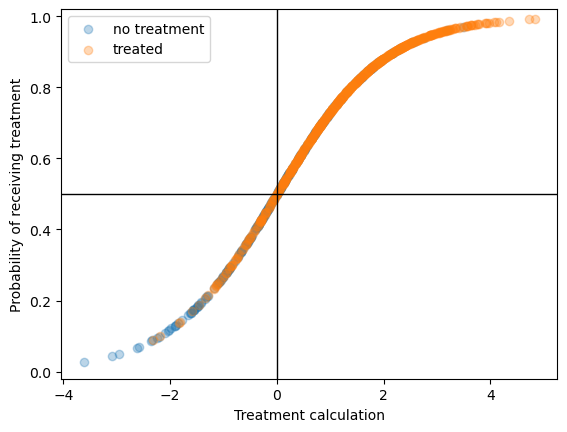

In [19]:
fig, ax = plt.subplots()
for i, label in enumerate(['no treatment', 'treated']):
    mask = df_gen['t_bin'] == i
    ax.scatter(
        df_gen.loc[mask, 't'],
        [sigmoid(x) for x in df_gen.loc[mask, 't'].values],
        label=label, alpha=0.3
    )
ax.axhline(0.5, lw=1, color='k')
ax.axvline(0.0, lw=1, color='k')
ax.legend()
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel('Treatment calculation')
ax.set_ylabel('Probability of receiving treatment')
plt.show()

Eyeball the correlations in the generated data:

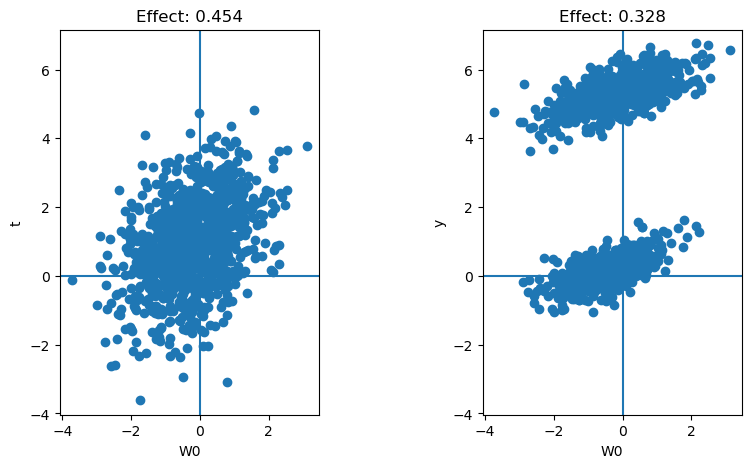

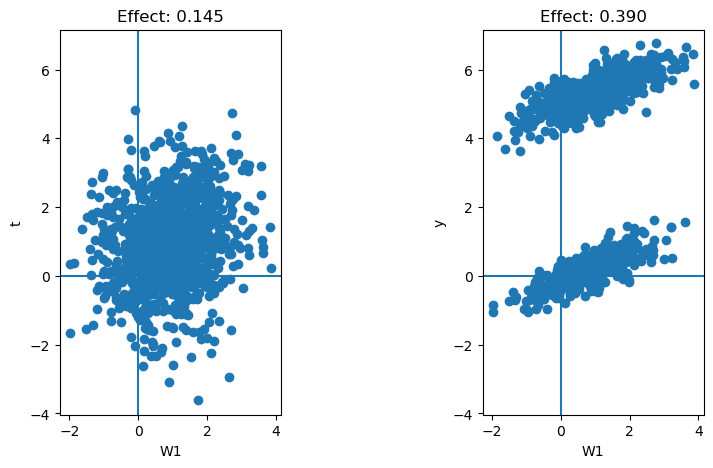

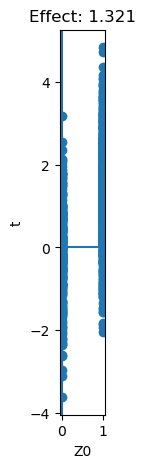

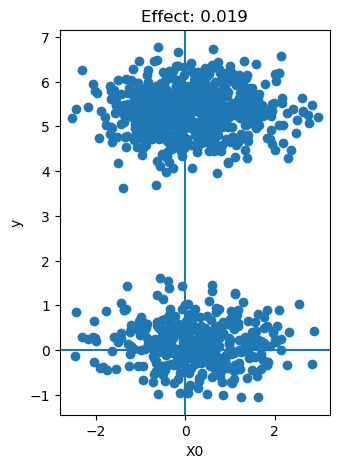

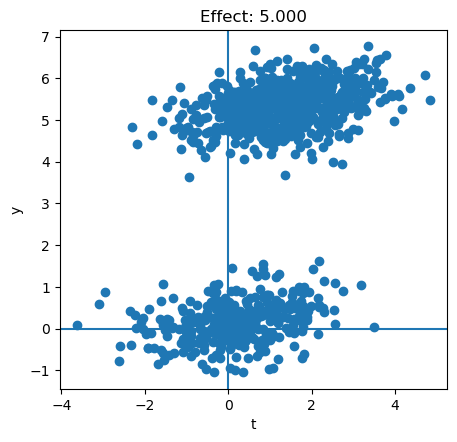

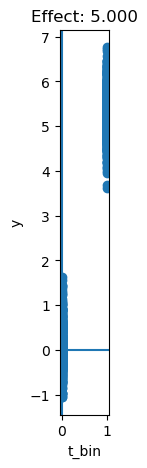

In [27]:
for c in df_gen.columns:
    if 'W' in c:
        c_t = causal_effect_dict[f'c_{c}_t']
        c_o = causal_effect_dict[f'c_{c}_y']
        fig, axs = plt.subplots(1, 2, figsize=(10, 5))
        axs[0].scatter(df_gen[c], df_gen['t'])
        axs[1].scatter(df_gen[c], df_gen['y'])
        axs[0].set_ylabel('t')
        axs[1].set_ylabel('y')
        axs[0].set_title(f'Effect: {c_t:.3f}')
        axs[1].set_title(f'Effect: {c_o:.3f}')
        xlim = [min([axs[0].get_xlim()[0], axs[1].get_xlim()[0]]), max([axs[0].get_xlim()[1], axs[1].get_xlim()[1]])]
        ylim = [min([axs[0].get_ylim()[0], axs[1].get_ylim()[0]]), max([axs[0].get_ylim()[1], axs[1].get_ylim()[1]])]
        for ax in axs:
            ax.set_xlabel(c)
            ax.axhline(0.0)
            ax.axvline(0.0)
            ax.set_aspect('equal')
            ax.set_xlim(xlim)
            ax.set_ylim(ylim)
            
        plt.show()
    elif 'Z' in c:
        c_t = causal_effect_dict[f'c_{c}_t']
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.scatter(df_gen[c], df_gen['t'])
        ax.set_xlabel(c)
        ax.set_ylabel('t')
        ax.set_title(f'Effect: {c_t:.3f}')
        ax.axhline(0.0)
        ax.axvline(0.0)
        ax.set_aspect('equal')
        plt.show()
    elif ('X' in c) | (c.startswith('t')):
        c_o = treatment_effects[0] if c.startswith('t') else causal_effect_dict[f'c_{c}_y']
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.scatter(df_gen[c], df_gen['y'])
        ax.set_xlabel(c)
        ax.set_ylabel('y')
        ax.set_title(f'Effect: {c_o:.3f}')
        ax.axhline(0.0)
        ax.axvline(0.0)
        ax.set_aspect('equal')
        plt.show()
    else:
        pass

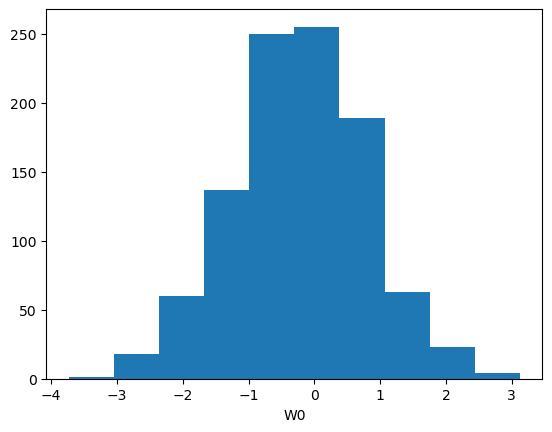

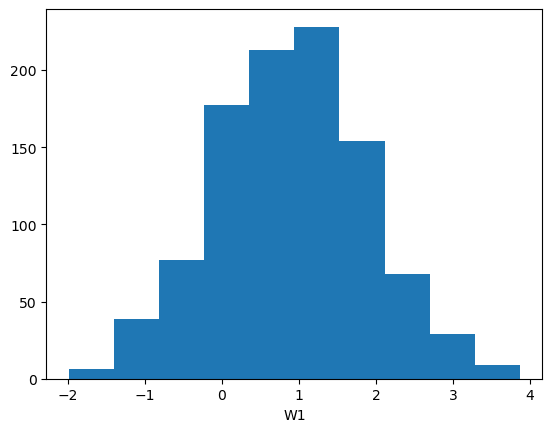

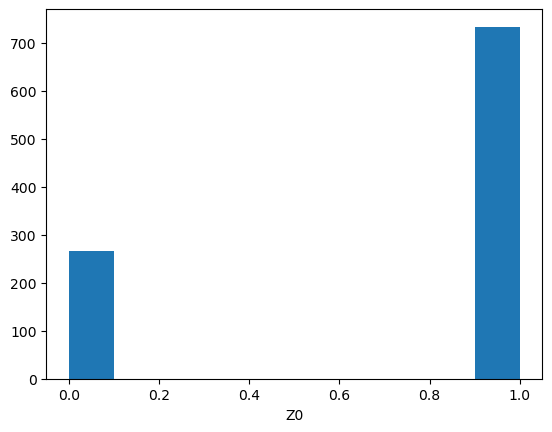

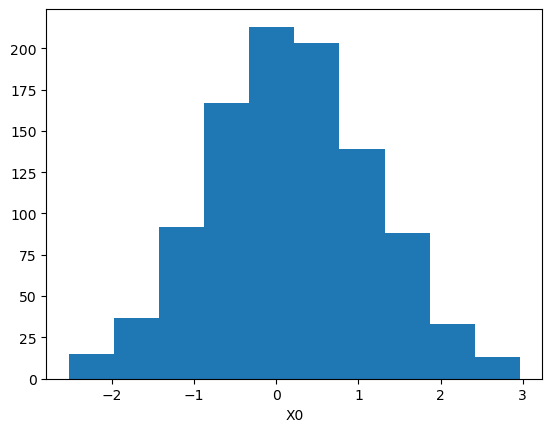

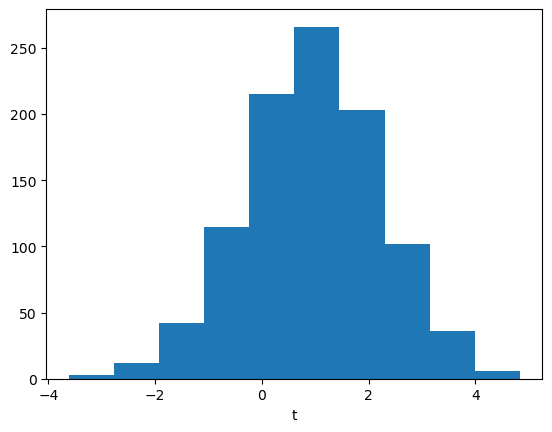

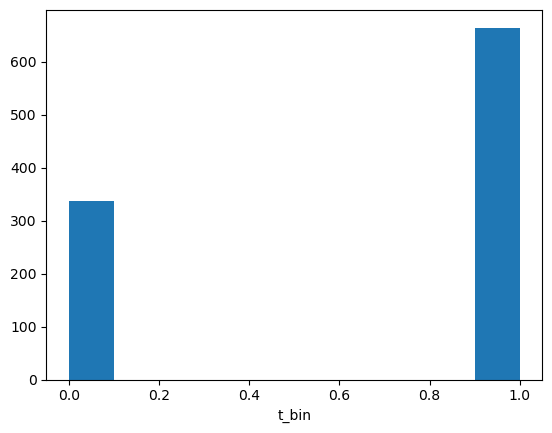

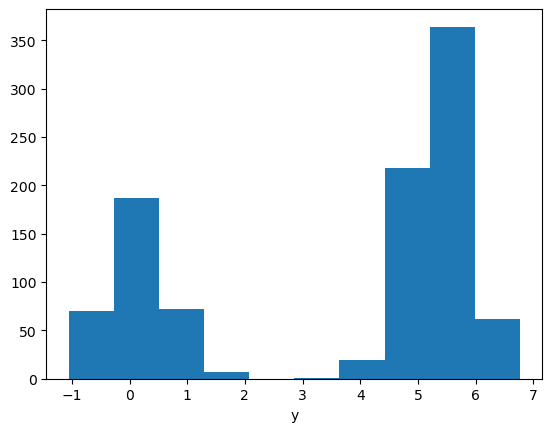

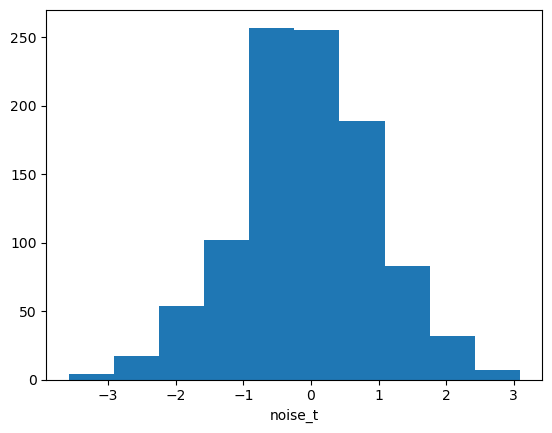

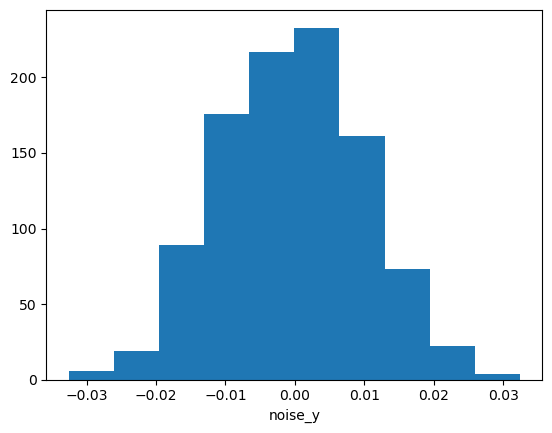

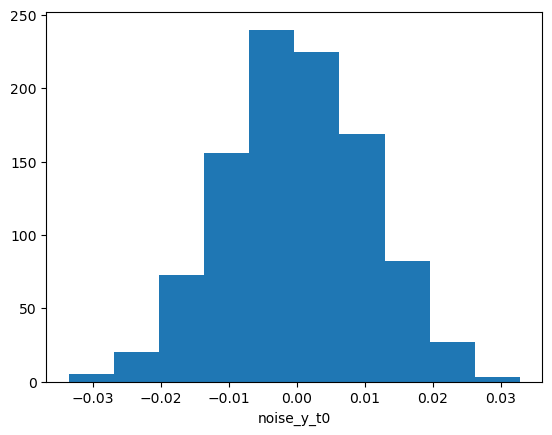

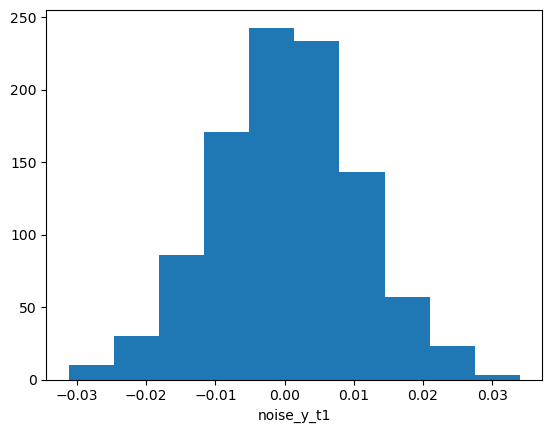

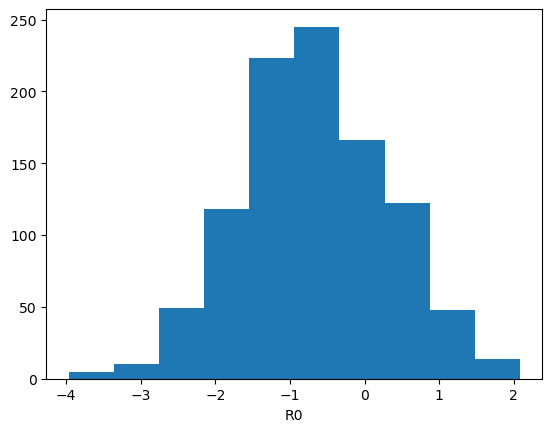

In [21]:
for c in df_gen.columns:
    try:
        plt.hist(df_gen[c])
    except TypeError:
        plt.hist(df_gen[c].astype(float))
    plt.xlabel(c)
    plt.show()

## Save data

Full data and disguised column names.

In [22]:
df_gen.columns

Index(['W0', 'W1', 'Z0', 'X0', 't', 't_bin', 'y', 'noise_t', 'noise_y',
       'noise_y_t0', 'noise_y_t1', 'R0'],
      dtype='object')

In [23]:
col_disguise_dict = {
    'W0': 'A',
    'W1': 'E',
    # 'W2': '',
    'Z0': 'D',
    'X0': 'B',
    'R0': 'C',
    # 't',
    't_bin': 'treatment',
    'y': 'outcome',
    # 'noise_t',
    # 'noise_y',
    # 'noise_y_t0',
    # 'noise_y_t1'
}

In [24]:
df_gen.to_csv(os.path.join('.', 'data', 'gen_data_full.csv'), index=False)
df_disguise = df_gen[list(col_disguise_dict.keys())].rename(columns=col_disguise_dict)
df_disguise = df_disguise[sorted(df_disguise.columns)]
df_disguise.to_csv(os.path.join('.', 'data', 'gen_data.csv'), index=False)

In [25]:
s_random_dict = pd.Series(random_dict)
s_random_dict.name = 'random'
s_random_dict.index.name = 'param'
s_random_dict.to_csv(os.path.join('.', 'data', 'random_dict.csv'))

s_causal_effect_dict = pd.Series(causal_effect_dict)
s_causal_effect_dict.name = 'causal_effect'
s_causal_effect_dict.index.name = 'param'
s_causal_effect_dict.to_csv(os.path.join('.', 'data', 'causal_effect_dict.csv'))

s_col_disguise_dict = pd.Series(col_disguise_dict)
s_col_disguise_dict.name = 'disguise'
s_col_disguise_dict.index.name = 'param'
s_col_disguise_dict.to_csv(os.path.join('.', 'data', 'col_disguise_dict.csv'))